# 02 · Drift detector and canary calibration

Reads `reports/drift_calibration.json` (produced by `make calibrate`). Compares the legacy rule
(PSI ≥ 0.20 over 9 features incl. `cycle_scaled`, 1e-6 bin floor) to the current rule
(8 monitored features, Jeffreys smoothing, chi-square noise floor) and the legacy point-estimate
canary rule to the paired non-inferiority test.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
DATA = ROOT / "data" / "reference"
REPORTS = ROOT / "reports"

# Reference categorical palette (fixed order) and recessive chart chrome.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c9c8c2", "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2,
    "axes.titleweight": "bold", "axes.titlesize": 11, "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "legend.frameon": False,
})

In [2]:
cal = json.loads((REPORTS / "drift_calibration.json").read_text())
print(cal["legacy_rule"]); print(cal["current_rule"]); print("trials per cell:", cal["trials"])

max PSI over 9 features incl. cycle_scaled, 1e-6 bin floor, >= 0.20
max PSI over 8 monitored features, Jeffreys smoothing, >= max(0.20, chi-square noise floor at 1% family-wise false-alarm rate)
trials per cell: 200


## False alarms when nothing has drifted

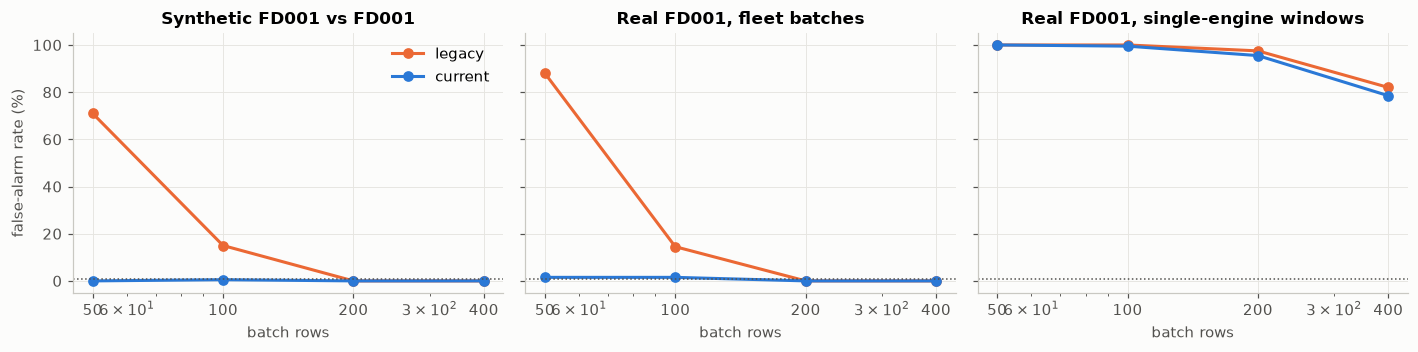

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.3), sharey=True)
panels = (
    ("Synthetic FD001 vs FD001", cal["synthetic_false_alarms"], "current"),
    ("Real FD001, fleet batches", cal["real"]["false_alarms"], "current"),
    ("Real FD001, single-engine windows", cal["real"]["false_alarms_single_engine_windows"], "current"),
)
for ax, (title, table, _) in zip(axes, panels):
    sizes = [int(s) for s in table]
    ax.plot(sizes, [100 * table[s]["legacy"] for s in table], color=ORANGE, marker="o", markersize=6, label="legacy")
    ax.plot(sizes, [100 * table[s]["current"] for s in table], color=BLUE, marker="o", markersize=6, label="current")
    ax.axhline(1, color="#52514e", linestyle=":", linewidth=1)
    ax.set(title=title, xlabel="batch rows", xscale="log", xticks=sizes, xticklabels=sizes)
axes[0].set_ylabel("false-alarm rate (%)")
axes[0].legend()
plt.tight_layout()

Single-engine windows alarm under *any* rule: consecutive rows from one or two engines sit at
one life stage, and the degradation-correlated sensors differ from the fleet reference. The fix
is operational (score fleet cross-sections), not a threshold.

## Sensitivity: injected `sensor_2` bias

FD002 {'50': '100%', '100': '100%', '200': '100%', '400': '100%'}
FD003 {'50': '86%', '100': '100%', '200': '100%', '400': '100%'}
FD004 {'50': '100%', '100': '100%', '200': '100%', '400': '100%'}


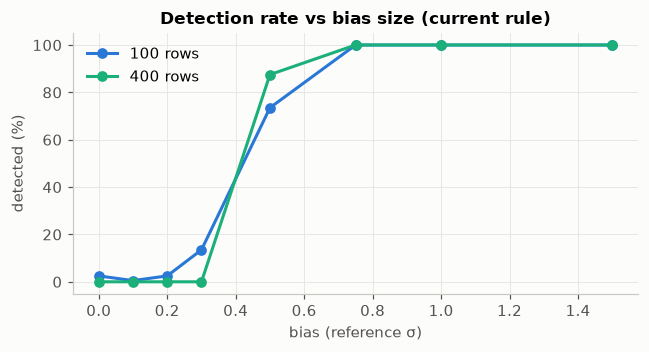

In [4]:
power = cal["real"]["power_sensor_2_bias_sigma"]
fig, ax = plt.subplots(figsize=(6, 3.3))
for (size, curve), color in zip(power.items(), (BLUE, AQUA)):
    levels = [float(k) for k in curve]
    ax.plot(levels, [100 * curve[k]["current"] for k in curve], color=color, marker="o", markersize=6, label=f"{size} rows")
ax.set(title="Detection rate vs bias size (current rule)", xlabel="bias (reference σ)", ylabel="detected (%)")
ax.legend()
plt.tight_layout()
for domain, table in cal["real"]["detection"].items():
    print(domain, {size: f"{100 * v['current']:.0f}%" for size, v in table.items()})

## Canary decision: operating characteristic

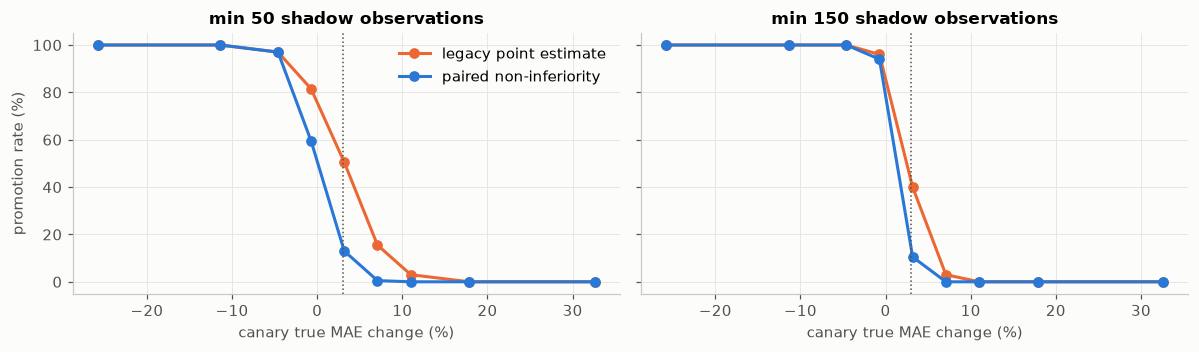

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.3), sharey=True)
for ax, (minimum, rows) in zip(axes, cal["canary"]["curves"].items()):
    change = [100 * r["true_relative_mae_change"] for r in rows]
    ax.plot(change, [100 * r["legacy_promote_rate"] for r in rows], color=ORANGE, marker="o", markersize=6, label="legacy point estimate")
    ax.plot(change, [100 * r["promote_rate"] for r in rows], color=BLUE, marker="o", markersize=6, label="paired non-inferiority")
    ax.axvline(100 * cal["canary"]["tolerance"], color="#52514e", linestyle=":", linewidth=1)
    ax.set(title=f"min {minimum} shadow observations", xlabel="canary true MAE change (%)")
axes[0].set_ylabel("promotion rate (%)")
axes[0].legend()
plt.tight_layout()

Right of the dotted tolerance line the canary is genuinely worse than allowed; the
non-inferiority test keeps those promotions near zero, at the cost of collecting more shadow
observations when the canary is close to the boundary.